# 03 · Ablation kiến trúc

Hai thí nghiệm bắt buộc còn lại, đều dùng hàm mất mát tốt nhất tìm được ở
notebook 02:

1. **Cách tăng mẫu**: `transpose` / `bilinear` / `unpool`
2. **Skip connection**: `full` / `half` / `none`

Cấu hình gốc đã chạy rồi nên chỉ cần thêm 4 lượt mới.

Người phụ trách: **SV A**.

In [1]:
# Chạy được cả trên Colab lẫn máy cá nhân
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not Path("unet-kvasir").exists():
    # !git clone <repo cua nhom> unet-kvasir
    pass
ROOT = Path("unet-kvasir") if Path("unet-kvasir").exists() else Path("..")
os.chdir(ROOT.resolve())
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

from src import *
print("Thư mục làm việc:", Path.cwd())
print("Thiết bị:", get_device())

Thư mục làm việc: /root/workspace/unet-kvasir
Thiết bị: cuda


In [2]:
BEST_LOSS = "bce_dice"   # cập nhật theo kết quả notebook 02
base = Config(loss_name=BEST_LOSS, epochs=120, seed=42)

up_configs = [base.replace(up_mode=m, skip_mode="full", tag="ablation_up")
              for m in UP_MODES]
skip_configs = [base.replace(up_mode="transpose", skip_mode=m, tag="ablation_skip")
                for m in SKIP_MODES]

for c in up_configs + skip_configs:
    print(f"{c.run_id:50s}")

bce_dice-transpose-full-s42-c6245d                
bce_dice-bilinear-full-s42-b9e54d                 
bce_dice-unpool-full-s42-af711c                   
bce_dice-transpose-full-s42-c6245d                
bce_dice-transpose-half-s42-72d2c7                
bce_dice-transpose-half_shallow-s42-55dfa7        
bce_dice-transpose-none-s42-4959d3                


Số tham số **không bằng nhau** giữa ba cách tăng mẫu và ba mức skip.
Nêu rõ điểm này trong báo cáo như một hạn chế của thiết kế thí nghiệm — giám
khảo hay hỏi đúng chỗ này.

In [3]:
for c in up_configs + skip_configs:
    m = build_model(c)
    print(f"{c.up_mode:10s} {c.skip_mode:5s} {count_parameters(m):>12,} tham số")
    del m

transpose  full    31,037,633 tham số
bilinear   full    34,520,193 tham số
unpool     full    32,083,073 tham số
transpose  full    31,037,633 tham số
transpose  half    30,853,313 tham số
transpose  half_shallow   28,088,513 tham số
transpose  none    27,904,193 tham số


In [4]:
results = run_sweep(up_configs + skip_configs)


----- [1/7] -----
[bỏ qua] bce_dice-transpose-full-s42-c6245d đã có trong log.

----- [2/7] -----
[bỏ qua] bce_dice-bilinear-full-s42-b9e54d đã có trong log.

----- [3/7] -----
[bỏ qua] bce_dice-unpool-full-s42-af711c đã có trong log.

----- [4/7] -----
[bỏ qua] bce_dice-transpose-full-s42-c6245d đã có trong log.

----- [5/7] -----
[bỏ qua] bce_dice-transpose-half-s42-72d2c7 đã có trong log.

----- [6/7] -----
[bỏ qua] bce_dice-transpose-half_shallow-s42-55dfa7 đã có trong log.

----- [7/7] -----
[bỏ qua] bce_dice-transpose-none-s42-4959d3 đã có trong log.


## Hai bảng ablation

In [5]:
import pandas as pd

df = RunLogger(base.log_csv).to_dataframe()
num = ["test_dice", "test_iou", "test_precision", "test_recall", "n_params"]
df[num] = df[num].astype(float)
df["epochs"] = df["epochs"].astype(int)
df["seed"] = df["seed"].astype(int)
df["lr"] = df["lr"].astype(float)

# Lọc theo CẤU HÌNH chứ không theo tag. Cấu hình gốc (transpose + full) đã chạy
# ở notebook trước với tag khác, lọc theo tag sẽ đánh rơi nó và bảng thiếu dòng.
same = ((df.loss_name == base.loss_name) & (df.epochs == base.epochs)
        & (df.seed == base.seed) & (df.lr == base.lr))

up_tbl = df[same & (df.skip_mode == "full")][["up_mode"] + num]
skip_tbl = df[same & (df.up_mode == "transpose")][["skip_mode"] + num]

print(f"=== Cách tăng mẫu ({len(up_tbl)}/{len(UP_MODES)}) ===")
print(up_tbl.sort_values("test_dice", ascending=False).round(4).to_markdown(index=False))
print(f"\n=== Skip connection ({len(skip_tbl)}/{len(SKIP_MODES)}) ===")
print(skip_tbl.sort_values("test_dice", ascending=False).round(4).to_markdown(index=False))

=== Cách tăng mẫu (4/3) ===
| up_mode   |   test_dice |   test_iou |   test_precision |   test_recall |    n_params |
|:----------|------------:|-----------:|-----------------:|--------------:|------------:|
| bilinear  |      0.8607 |     0.789  |           0.8832 |        0.8293 | 3.45202e+07 |
| transpose |      0.8507 |     0.7727 |           0.8995 |        0.7952 | 3.10376e+07 |
| transpose |      0.8507 |     0.7727 |           0.8995 |        0.7952 | 3.10376e+07 |
| unpool    |      0.8433 |     0.7638 |           0.8486 |        0.8402 | 3.20831e+07 |

=== Skip connection (5/4) ===
| skip_mode    |   test_dice |   test_iou |   test_precision |   test_recall |    n_params |
|:-------------|------------:|-----------:|-----------------:|--------------:|------------:|
| half         |      0.8519 |     0.7744 |           0.8713 |        0.8475 | 3.08533e+07 |
| half_shallow |      0.8513 |     0.7745 |           0.8839 |        0.8343 | 2.80885e+07 |
| full         |      0.8507 

Hai dòng `n/N` ở đầu mỗi bảng là chốt chặn: thiếu cấu hình nào là thấy ngay
thay vì âm thầm trôi qua.

## Soi checkerboard artifact

Phải phóng to sát biên polyp mới thấy. Không zoom thì phần bình luận trong
báo cáo sẽ thành nói suông.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from scipy import ndimage

splits = load_splits(base.split_dir)
test_ds = KvasirSegDataset(base.data_root, splits["test"],
                           SegTransform(base.image_size, train=False))
device = get_device()

# Chọn ảnh có polyp cỡ vừa: polyp quá lớn thì biên nằm sát mép, quá nhỏ thì
# không đủ biên để soi.
areas = np.array([(np.asarray(Image.open(Path(base.data_root) / "masks" / n)
                              .convert("L")) > 127).mean() for n in splits["test"]])
idx = int(np.argmin(np.abs(areas - 0.20)))
img, msk = test_ds[idx]

# Cửa sổ crop TỰ ĐỘNG, đặt vào chỗ biên polyp uốn lượn nhất. Box cố định
# thường rơi vào vùng biên phẳng, nơi mọi cấu hình đều giống nhau.
m = msk[0].numpy() > 0.5
edge = m ^ ndimage.binary_erosion(m, iterations=2)
dens = ndimage.uniform_filter(edge.astype(float), size=24)
cy, cx = np.unravel_index((dens * edge).argmax(), dens.shape)
S = 48
x = int(np.clip(cx - S // 2, 0, base.image_size - S))
y = int(np.clip(cy - S // 2, 0, base.image_size - S))
print(f"ảnh #{idx} (polyp {areas[idx]:.3f}), cửa sổ crop ({x}, {y}, {S}, {S})")

ảnh #143 (polyp 0.200), cửa sổ crop (155, 200, 48, 48)


Vẽ **bản đồ xác suất**, không phải mask đã nhị phân hoá. Đây là điểm mấu chốt:
ngưỡng 0.5 xoá sạch mọi dao động nhỏ, mà checkerboard artifact chính là dao
động nhỏ — vẽ mask nhị phân thì ba ô sẽ giống hệt nhau và hình vô dụng.

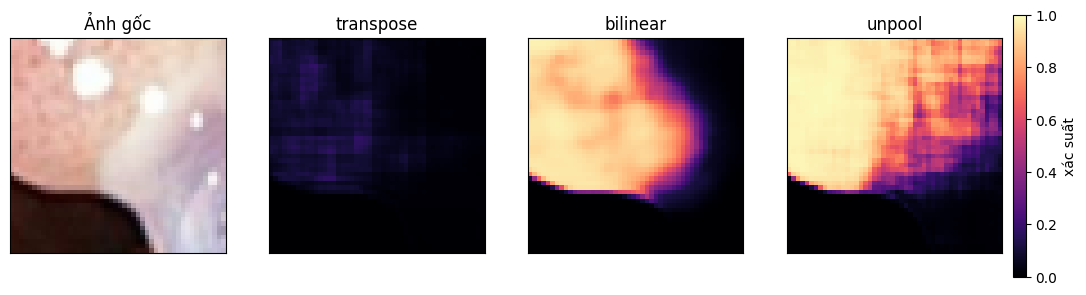

In [7]:
fig, axes = plt.subplots(1, 1 + len(UP_MODES), figsize=(3.3 * (1 + len(UP_MODES)), 3.4))
axes[0].imshow(denormalize(img)[y:y + S, x:x + S])
axes[0].set_title("Ảnh gốc")

for ax, cfg_ in zip(axes[1:], up_configs):
    model = load_best(build_model(cfg_, device), cfg_.ckpt_path, device)
    with torch.no_grad():
        prob = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0, 0].cpu().numpy()
    im = ax.imshow(prob[y:y + S, x:x + S], cmap="magma", vmin=0, vmax=1,
                   interpolation="nearest")
    ax.set_title(cfg_.up_mode)
    del model

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label="xác suất")
fig.savefig(f"{base.fig_dir}/zoom_upmode_prob.png", dpi=200, bbox_inches="tight")

**Nếu không thấy vân ô cờ, đó vẫn là kết quả hợp lệ.** Viết rằng nhóm không
quan sát được checkerboard artifact, và giải thích: `ConvTranspose2d(kernel=2,
stride=2)` có kernel chia hết cho stride nên các cửa sổ tăng mẫu không chồng
lấn — chồng lấn không đều mới là điều kiện sinh artifact. Tài liệu thường minh
hoạ bằng kernel 3 hoặc 4 với stride 2.

Khi đó chênh lệch Dice giữa `bilinear` và `transpose` **không** quy được cho
việc tránh artifact, và phải tìm lời giải thích khác (số tham số, tính trơn của
phép nội suy).

## Câu hỏi cần trả lời

1. `bilinear` có ít artifact hơn `transpose` không? Có bằng chứng hình ảnh chưa?
2. Bỏ skip làm Dice tụt bao nhiêu? Tụt nhiều nhất ở loại ảnh nào — polyp nhỏ
   hay polyp có biên phức tạp?
3. `half skip` nằm ở đâu giữa `full` và `none`? Nếu nó gần `full` thì kết luận
   là gì về vai trò của các tầng nông?